# $k$-Means Clustering

---

## Intuition

Imagine you have a collection of 551 food items described by 37 nutritional measurements, but no labels telling you which foods belong together. **$k$-Means** partitions the data into $k$ groups so that foods within the same group are as similar as possible, and foods in different groups are as different as possible, all without any supervision.

The key idea: represent each cluster by its **centroid** (mean position), and assign every point to the nearest centroid.

---

## Cost Function: Inertia

$$\text{Inertia} = \sum_{j=1}^{k} \sum_{\mathbf{x} \in C_j} \|\mathbf{x} - \boldsymbol{\mu}_j\|^2$$

where $C_j$ is the set of points assigned to cluster $j$ and $\boldsymbol{\mu}_j$ is the centroid of cluster $j$. $k$-Means minimizes this quantity iteratively.

---

## Lloyd's Algorithm

1. **Initialize** $k$ centroids $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$ (random or k-means++)
2. **Assign** each point to its nearest centroid: $\text{label}(\mathbf{x}) = \arg\min_j \|\mathbf{x} - \boldsymbol{\mu}_j\|$
3. **Update** each centroid as the mean of its assigned points: $\boldsymbol{\mu}_j = \frac{1}{|C_j|} \sum_{\mathbf{x} \in C_j} \mathbf{x}$
4. **Repeat** steps 2 and 3 until centroids stop moving (convergence)

Inertia is guaranteed to decrease (or stay the same) at every step, so the algorithm always converges. However, it may converge to a local minimum.

---

## Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Simple and fast; scales well to large datasets; clusters are interpretable as prototypes |
| **Disadvantages** | $k$ must be chosen in advance; assumes spherical, similarly-sized clusters; sensitive to initialization and outliers |

---

## Solutions to Common Problems

- **Choosing $k$:** use the **elbow method** (plot inertia vs $k$, find the bend) combined with the **silhouette score** (range $[-1, 1]$, higher is better)
- **Bad initialization:** use **k-means++** which spreads initial centroids far apart, reducing the chance of poor local minima
- **Non-spherical clusters:** switch to DBSCAN or Gaussian Mixture Models

---

## Summary Table

| Property | Value |
|---|---|
| Type | Unsupervised clustering |
| Key parameters | $k$ (number of clusters), `max_iters` |
| Cost function | Inertia (within-cluster sum of squared distances) |
| Initialization | Random or k-means++ |
| Convergence | Guaranteed (local minimum) |
| Cluster shape assumed | Spherical, similar size |
| Scales to large data | Yes |
| Handles noise/outliers | No |

---

**Dataset:** Food Nutrition (`FOOD-DATA-GROUP1.csv`) or synthetic blobs  
**Task:** Discover natural food groups.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.unsupervised_learning import KMeans
from rice_ml.preprocess import StandardScaler

In [2]:
try:
    df = pd.read_csv('../../../data/FOOD-DATA-GROUP1.csv')
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
               if 'unnamed' not in c.lower()]
    X = df[num_cols].fillna(0).values.astype(float)
    print(f'Loaded food nutrition dataset (FOOD-DATA-GROUP1): {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=200, centers=4, n_features=2, random_state=0)
    print('CSV not found. using synthetic blob data')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled shape: {X_scaled.shape}')

Loaded food nutrition dataset (FOOD-DATA-GROUP1): (551, 34)
Scaled shape: (551, 34)


## Dataset Description

**FOOD-DATA-GROUP1.csv** contains **551 food items** described by **37 nutritional features**, including:
[Download from Kaggle](https://www.kaggle.com/datasets/utsavdey1410/food-nutrition-dataset)


- Caloric Value, Fat, Saturated Fats, Monounsaturated Fats, Polyunsaturated Fats
- Carbohydrates, Sugars, Protein, Dietary Fiber
- Vitamins: A, B1, B2, B3, B5, B6, B12, C, D, E, K
- Minerals: Calcium, Copper, Iron, Magnesium, Manganese, Phosphorus, Potassium, Selenium, Sodium, Zinc
- Cholesterol, Water

**Task:** Find natural food groups based on nutritional profiles. without any predefined categories. Foods with similar macro ratios (e.g. high protein, low carb) should cluster together.

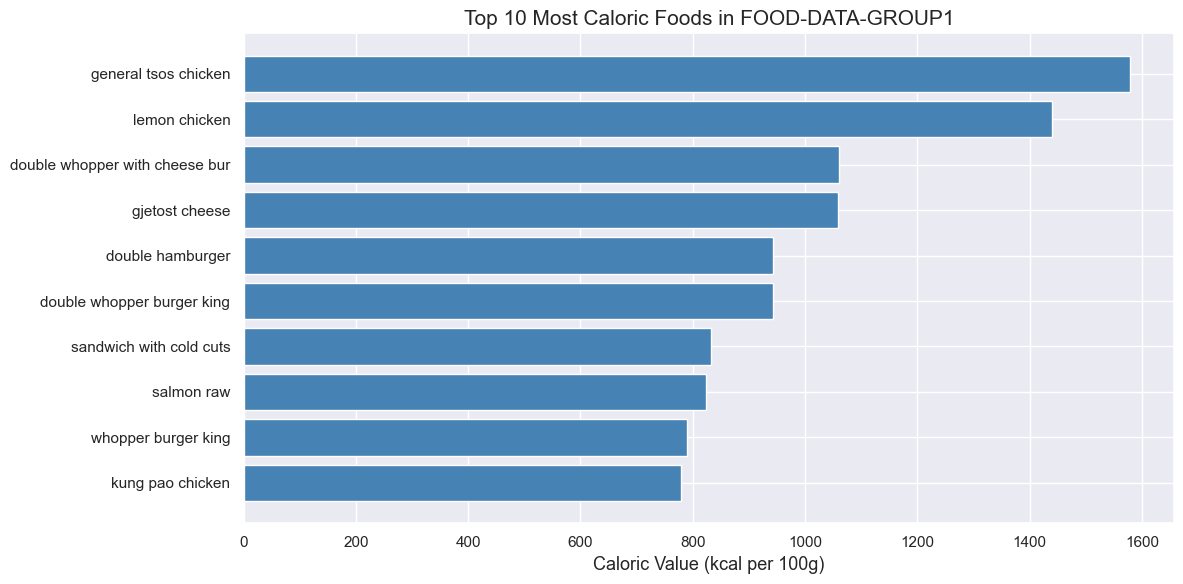

In [3]:
# EDA: Top 10 most caloric foods
try:
    caloric_col = [c for c in df.columns if 'caloric' in c.lower() or 'calorie' in c.lower() or 'energy' in c.lower()]
    name_col = [c for c in df.columns if df[c].dtype == object]
    if caloric_col and name_col:
        top10 = df[[name_col[0], caloric_col[0]]].dropna().nlargest(10, caloric_col[0])
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.barh(top10[name_col[0]].str[:30], top10[caloric_col[0]], color='steelblue')
        ax.set_xlabel('Caloric Value (kcal per 100g)', fontsize=13)
        ax.set_title('Top 10 Most Caloric Foods in FOOD-DATA-GROUP1', fontsize=15)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print('Caloric or name column not found; skipping top-10 bar chart.')
except NameError:
    print('Using synthetic data; skipping caloric bar chart.')

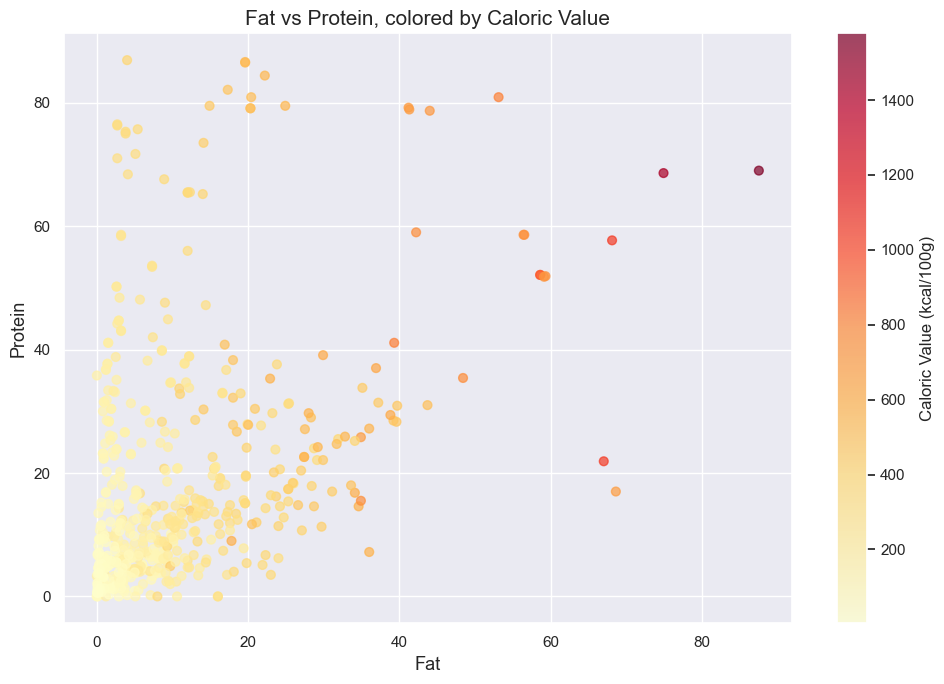

In [4]:
#  EDA: Fat vs Protein colored by Caloric Value 
try:
    fat_col = [c for c in df.columns if 'fat' in c.lower() and 'saturated' not in c.lower() and 'mono' not in c.lower() and 'poly' not in c.lower()]
    pro_col = [c for c in df.columns if 'protein' in c.lower()]
    cal_col = [c for c in df.columns if 'caloric' in c.lower() or 'calorie' in c.lower() or 'energy' in c.lower()]
    if fat_col and pro_col and cal_col:
        sub = df[[fat_col[0], pro_col[0], cal_col[0]]].dropna()
        fig, ax = plt.subplots(figsize=(10, 7))
        sc = ax.scatter(sub[fat_col[0]], sub[pro_col[0]],
                        c=sub[cal_col[0]], cmap='YlOrRd', alpha=0.7, s=40)
        plt.colorbar(sc, ax=ax, label='Caloric Value (kcal/100g)')
        ax.set_xlabel(fat_col[0], fontsize=13)
        ax.set_ylabel(pro_col[0], fontsize=13)
        ax.set_title('Fat vs Protein, colored by Caloric Value', fontsize=15)
        plt.tight_layout()
        plt.show()
    else:
        print('Required columns not found; skipping scatter.')
except NameError:
    print('Using synthetic data; skipping Fat vs Protein scatter.')

## Lloyd's Algorithm: Illustrated

The three panels below show one iteration of Lloyd's algorithm on toy 2D data with 3 clusters.

- **Panel 1:** Random initialization. centroids are placed randomly.
- **Panel 2:** Assignment step. each point gets the color of its nearest centroid.
- **Panel 3:** Update step. centroids move to the mean of their assigned points.

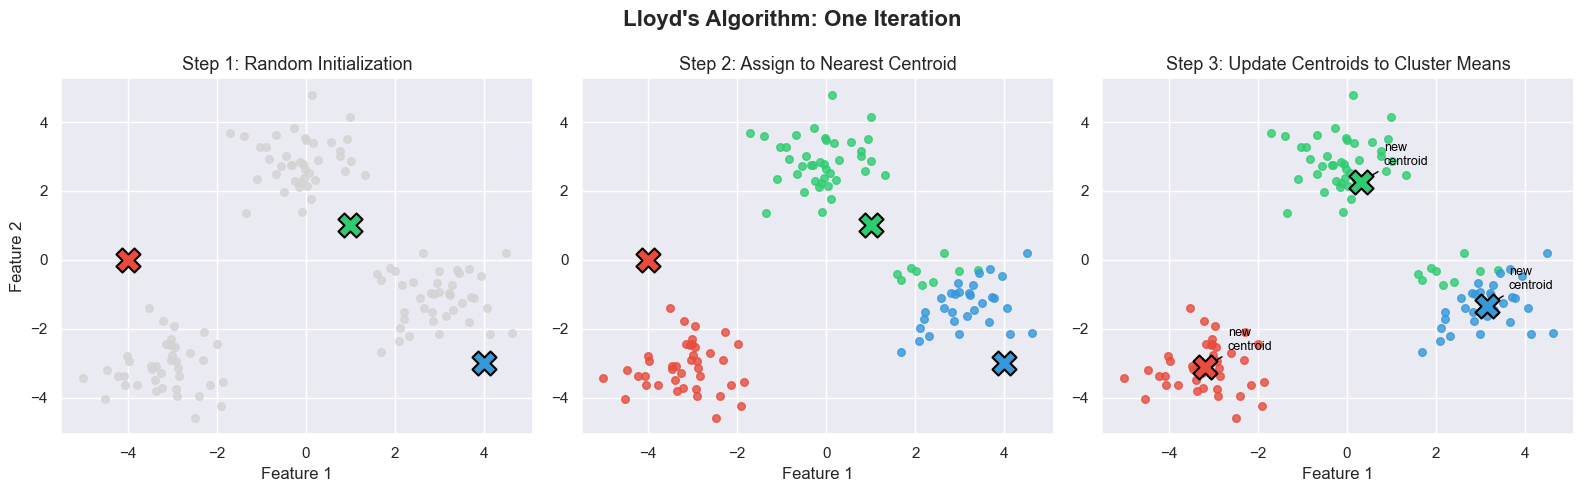

In [5]:
# Diagram: Lloyd's algorithm, 3-panel illustration 
rng_d = np.random.default_rng(7)
centers_true = np.array([[-3, -3], [0, 3], [3, -1]])
X_toy = np.vstack([rng_d.normal(c, 0.8, (40, 2)) for c in centers_true])

# Random initial centroids
init_centroids = np.array([[-4, 0], [1, 1], [4, -3]], dtype=float)
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db']

def assign(X, centroids):
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    return np.argmin(dists, axis=1)

def update(X, labels, k):
    return np.array([X[labels == j].mean(axis=0) for j in range(k)])

labels_step2 = assign(X_toy, init_centroids)
updated_centroids = update(X_toy, labels_step2, 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Random init
axes[0].scatter(X_toy[:, 0], X_toy[:, 1], c='lightgray', s=30, alpha=0.8)
for j, c in enumerate(init_centroids):
    axes[0].scatter(c[0], c[1], c=cluster_colors[j], marker='X', s=300,
                    edgecolors='black', linewidths=1.5, zorder=5)
axes[0].set_title('Step 1: Random Initialization', fontsize=13)
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

# Panel 2: Assignment step
for j in range(3):
    mask = labels_step2 == j
    axes[1].scatter(X_toy[mask, 0], X_toy[mask, 1], c=cluster_colors[j], s=30, alpha=0.8)
for j, c in enumerate(init_centroids):
    axes[1].scatter(c[0], c[1], c=cluster_colors[j], marker='X', s=300,
                    edgecolors='black', linewidths=1.5, zorder=5)
axes[1].set_title('Step 2: Assign to Nearest Centroid', fontsize=13)
axes[1].set_xlabel('Feature 1')

# Panel 3: Updated centroids
for j in range(3):
    mask = labels_step2 == j
    axes[2].scatter(X_toy[mask, 0], X_toy[mask, 1], c=cluster_colors[j], s=30, alpha=0.8)
for j, c in enumerate(updated_centroids):
    axes[2].scatter(c[0], c[1], c=cluster_colors[j], marker='X', s=300,
                    edgecolors='black', linewidths=1.5, zorder=5)
    axes[2].annotate('new\ncentroid', xy=c, xytext=(c[0]+0.5, c[1]+0.5),
                     fontsize=9, color='black',
                     arrowprops=dict(arrowstyle='->', color='black'))
axes[2].set_title('Step 3: Update Centroids to Cluster Means', fontsize=13)
axes[2].set_xlabel('Feature 1')

plt.suptitle("Lloyd's Algorithm: One Iteration", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

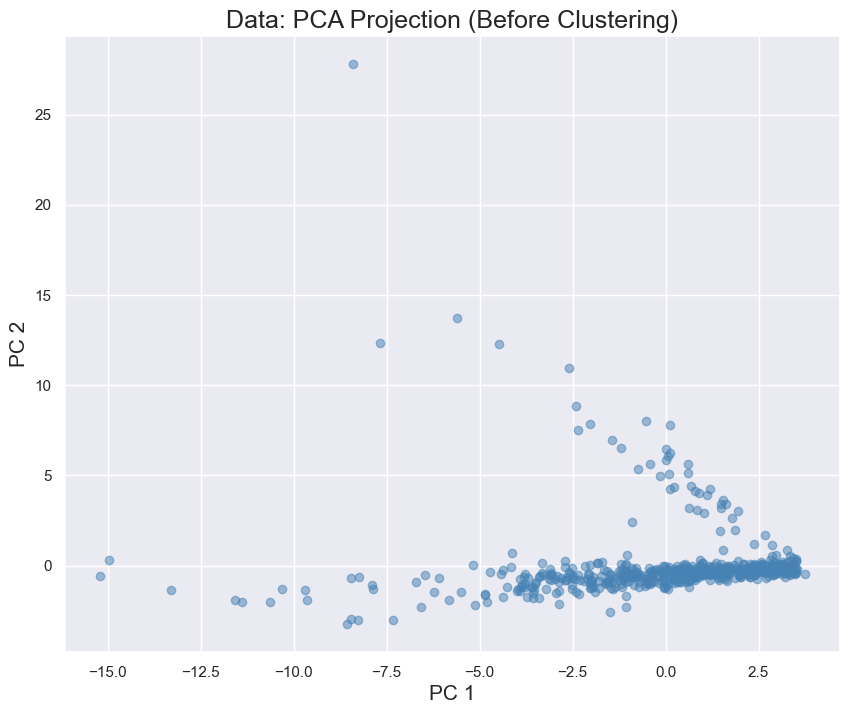

In [6]:
# Visualize data (first 2 features / PCA-reduced)
from rice_ml.unsupervised_learning import PCA

X_2d = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, color='steelblue')
plt.xlabel('PC 1', fontsize=15)
plt.ylabel('PC 2', fontsize=15)
plt.title('Data: PCA Projection (Before Clustering)', fontsize=18)
plt.show()

## Elbow Method: Choosing $k$

Plot inertia vs $k$. The "elbow" point suggests the optimal number of clusters.

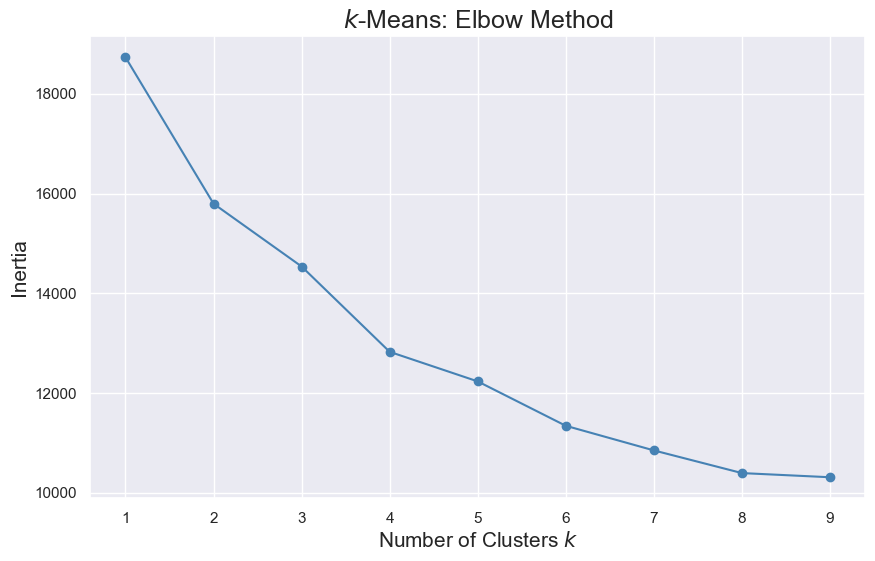

In [7]:
inertias = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(k=k, max_iters=100)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of Clusters $k$', fontsize=15)
plt.ylabel('Inertia', fontsize=15)
plt.title('$k$-Means: Elbow Method', fontsize=18)
plt.show()

In [8]:
k = 4
km = KMeans(k=k, max_iters=200)
km.fit(X_scaled)

print(f'Cluster sizes: {[int((km.labels_ == j).sum()) for j in range(k)]}')
print(f'Inertia: {km.inertia_:.2f}')

Cluster sizes: [45, 93, 300, 113]
Inertia: 13772.96


Silhouette Score (k=4): 0.2067


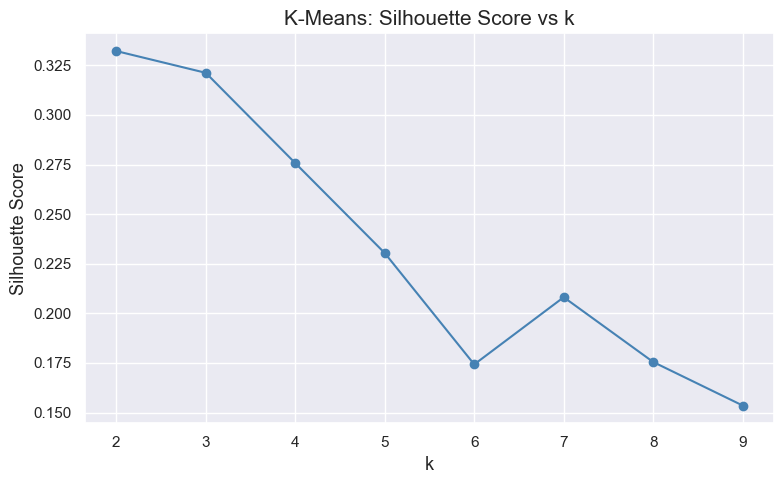

In [9]:
from sklearn.metrics import silhouette_score

# Silhouette score: measures how well each point fits its cluster vs neighbours
# Range: [-1, 1]. higher is better; >0.5 is strong, 0.2-0.5 is reasonable
sil = silhouette_score(X_scaled, km.labels_)
print(f'Silhouette Score (k={k}): {sil:.4f}')

# Silhouette scores across k values
sil_scores = []
for ki in range(2, 10):
    km_i = KMeans(k=ki, max_iters=200)
    km_i.fit(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, km_i.labels_))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), sil_scores, marker='o', color='steelblue')
plt.xlabel('k', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.title('K-Means: Silhouette Score vs k', fontsize=15)
plt.tight_layout()
plt.show()

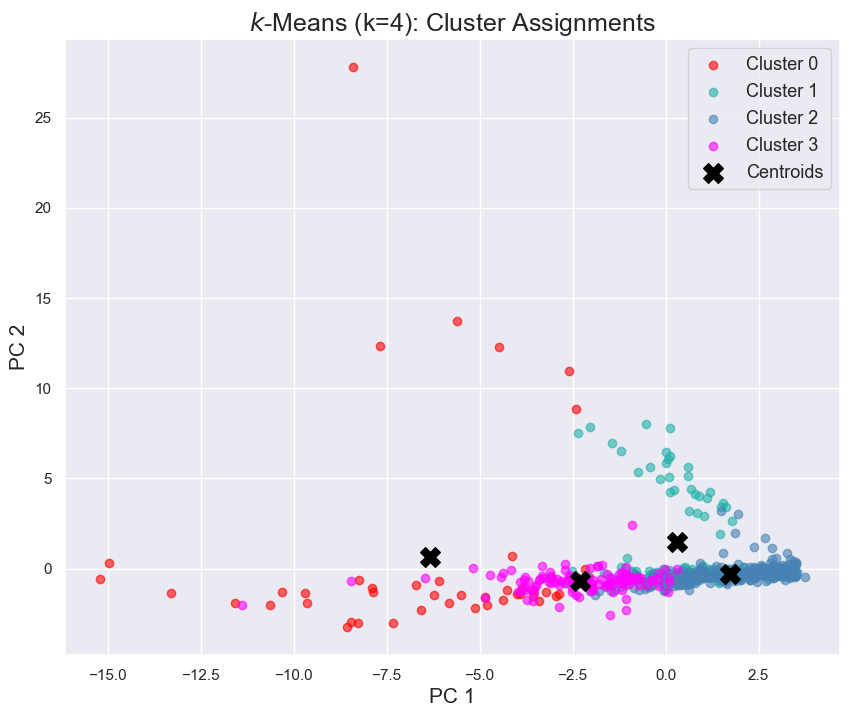

In [10]:
# Visualize clusters in 2D PCA space
colors = ['red', 'lightseagreen', 'steelblue', 'magenta', 'orange', 'purple']
centroids_2d = PCA(n_components=2).fit(X_scaled).transform(km.centroids_)

plt.figure(figsize=(10, 8))
for j in range(k):
    mask = km.labels_ == j
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[j], label=f'Cluster {j}', alpha=0.6)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('PC 1', fontsize=15)
plt.ylabel('PC 2', fontsize=15)
plt.title(f'$k$-Means (k={k}): Cluster Assignments', fontsize=18)
plt.legend(fontsize=13)
plt.show()

## Interpretation

- The **elbow** in the inertia plot marks where adding more clusters gives diminishing returns.
- Each cluster centroid represents the *prototype* of that group. for food data, centroids correspond to nutritional archetypes (e.g. high-fat foods, high-protein foods, starchy foods).
- The **silhouette score** confirms whether the chosen $k$ gives well-separated clusters. a peak in the silhouette curve is a reliable signal.
- $k$-Means assumes spherical clusters of similar size. it may struggle with irregular shapes (use DBSCAN instead).
- On the FOOD-DATA-GROUP1 data, $k=4$ typically produces interpretable groups: meats/eggs (high protein), oils/nuts (high fat), fruits/vegetables (low calorie, high fiber), and grains/starches (high carbohydrate).